In [1]:
from common import *

get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [287922]

In [ ]:
ca1_baseline = get("interface._ca1_culture_baseline").components[0]
df = ca1_baseline.components[-1].get_best()['y'].iloc[-1]
df[df.index.str.contains('firing rate')]

PYR firing rate         0.295280
CCKBC firing rate     891.772583
BS firing rate        263.544647
AAC firing rate       189.415863
PVBC firing rate      390.529114
IS1 firing rate       318.704102
IS2 firing rate        93.541214
IS3 firing rate      2617.879395
OLM firing rate       520.922424
IVY firing rate       327.893799
NGFC firing rate      221.026459
SCA firing rate        33.699234
Name: 86, dtype: float32

{'AAC firing rate': 18.0, 'AAC mean fraction active per time bin': 0.92, 'AAC state': {'v': {'margin': 2.0, 'threshold': -43.1}}, 'AAC std fraction active per time bin': 0.225, 'BS firing rate': 18.0, 'BS mean fraction active per time bin': 0.92, 'BS state': {'v': {'margin': 2.0, 'threshold': -43.1}}, 'BS std fraction active per time bin': 0.225, 'CCKBC firing rate': 9.0, 'CCKBC mean fraction active per time bin': 0.9, 'CCKBC state': {'v': {'margin': 2.0, 'threshold': -43.1}}, 'CCKBC std fraction active per time bin': 0.2, 'IS1 firing rate': 17.0, 'IS1 mean fraction active per time bin': 0.96, 'IS1 state': {'v': {'margin': 2.0, 'threshold': -43.1}}, 'IS1 std fraction active per time bin': 0.16, 'IS2 firing rate': 17.0, 'IS2 mean fraction active per time bin': 0.96, 'IS2 state': {'v': {'margin': 2.0, 'threshold': -43.1}}, 'IS2 std fraction active per time bin': 0.16, 'IS3 firing rate': 17.0, 'IS3 mean fraction active per time bin': 0.96, 'IS3 state': {'v': {'margin': 2.0, 'threshold': -

## Overview

In [3]:
_ca1_culture = get("interface._ca1_culture")

data = []
for c in _ca1_culture.components:
    data.append({
        'directory': c.local_directory(),
        'label': c.label(),
        'epochs': len(c.load_h5()['epochs']),
        'last_epoch': c.load_h5()['epochs'][-1]
    })

pd.DataFrame(data)

numprocs=1


2025-12-12 12:35:29.728734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-12 12:35:29.749114: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-12 12:35:29.749153: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-12 12:35:29.762503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-12 12:35:30.767713: W tensorflow/compiler/tf

,directory,label,epochs,last_epoch
0,./index/068fd48e-0749-7c06-8000-a0207cffe929,miv_simulator.optimize_network::O:gpr/C:-/S:-,1062,96
1,./index/068fd487-6969-72b8-8000-eaab4fbeeca3,miv_simulator.optimize_network::O:megp/C:-/S:-,892,78
2,./index/068fd48d-d124-7de3-8000-bb5cc6e95f52,miv_simulator.optimize_network::O:joint-c+o/C:...,572,48


# Timing and compute

In [32]:
parsing = False
stats = {}
for line in load_file('figures/data/ca1_slice-time.txt').split('\n'):
    if line.startswith("INFO:miv_simulator.network:Execution time"):
        parsing = True
        continue

    if not parsing:
        continue

    c = line[:-3].split(' ')

    key = " ".join(c[:-1]).replace('  ', '').replace(' in', '').replace(':', '')
    stats.setdefault(key, [])
    stats[key].append(float(c[-1]))


    if "voltage transfer time" in line:
        parsing = False

stats

{'created cells': [27.5, 26.6, 27.5, 26.9, 26.9],
 'connected cells': [216.2, 214.3, 216.0, 215.3, 215.3],
 'created gap junctions': [0.0, 0.0, 0.0, 0.0, 0.0],
 'ran simulation': [3719.8, 3895.2, 3824.0, 3801.9, 3801.9],
 'spike communication time': [119.1, 118.2, 126.1, 117.7, 117.7],
 'event handling time': [0.0, 0.0, 0.0, 0.0, 0.0],
 'numericaltegration time': [0.0, 0.0, 0.0, 0.0, 0.0],
 'voltage transfer time': [0.0, 0.0, 0.0, 0.0, 0.0]}

In [33]:
eval_time = np.mean(stats['ran simulation'])
eval_time_std = np.std(stats['ran simulation'])
print(eval_time, '+-', eval_time_std)

3808.56 +- 56.0569924273501


In [34]:
stash('figure5-timing-stats', stats)

# Feature Evaluation

In [5]:
# preprocessing large-scale simulation results
ca1_culture_eval_data = {}

ca1_culture_eval_data['target_populations'] = load_file(
    f"./ca1_network_runs/features_all/response_0.p"
)['target_populations']

for suffix in ['_opt', '_none']:

    if (population_spiking := load_file(f'figures/data/ca1_culture{suffix}_population_spiking.p', None)) is None:
        population_spiking = {}
        i = 0
        while True:
            try:
                data = load_file(f"./run-p/features{suffix}/response_{i}.p")['pop_spike_dict']
            except:
                break
            for population, spiking in data.items():
                for gid, spiketrain in spiking.items():
                    population_spiking.setdefault(population, {})
                    population_spiking[population].setdefault(gid, [])
                    for instance in spiketrain:
                        population_spiking[population][gid].extend(instance.flatten().tolist())
            i+= 1

        save_file(f'figures/data/ca1_culture{suffix}_population_spiking.p', population_spiking)


    def _flatten(items):
        for item in items:
            if isinstance(item, (list, tuple)):
                yield from _flatten(item)
            else:
                yield item

    spiking = {}
    for pop, v in population_spiking.items():
        all_i = []
        all_t = []
        for gid, vals in v.items():
            for val in vals:
                all_i.append(gid)
                all_t.append(val)
        all_i = np.array(all_i)
        all_t = np.array(all_t)
        order = np.argsort(all_t)

        spiking[pop] = {
            'i': all_i[order],
            't': all_t[order],
        }

    ca1_culture_eval_data[suffix.replace('_', '')] = spiking

stash("figure5-ca1_culture_eval_data.p", ca1_culture_eval_data)

In [2]:
ca1_culture_eval_data = restore('figure5-ca1_culture_eval_data.p')

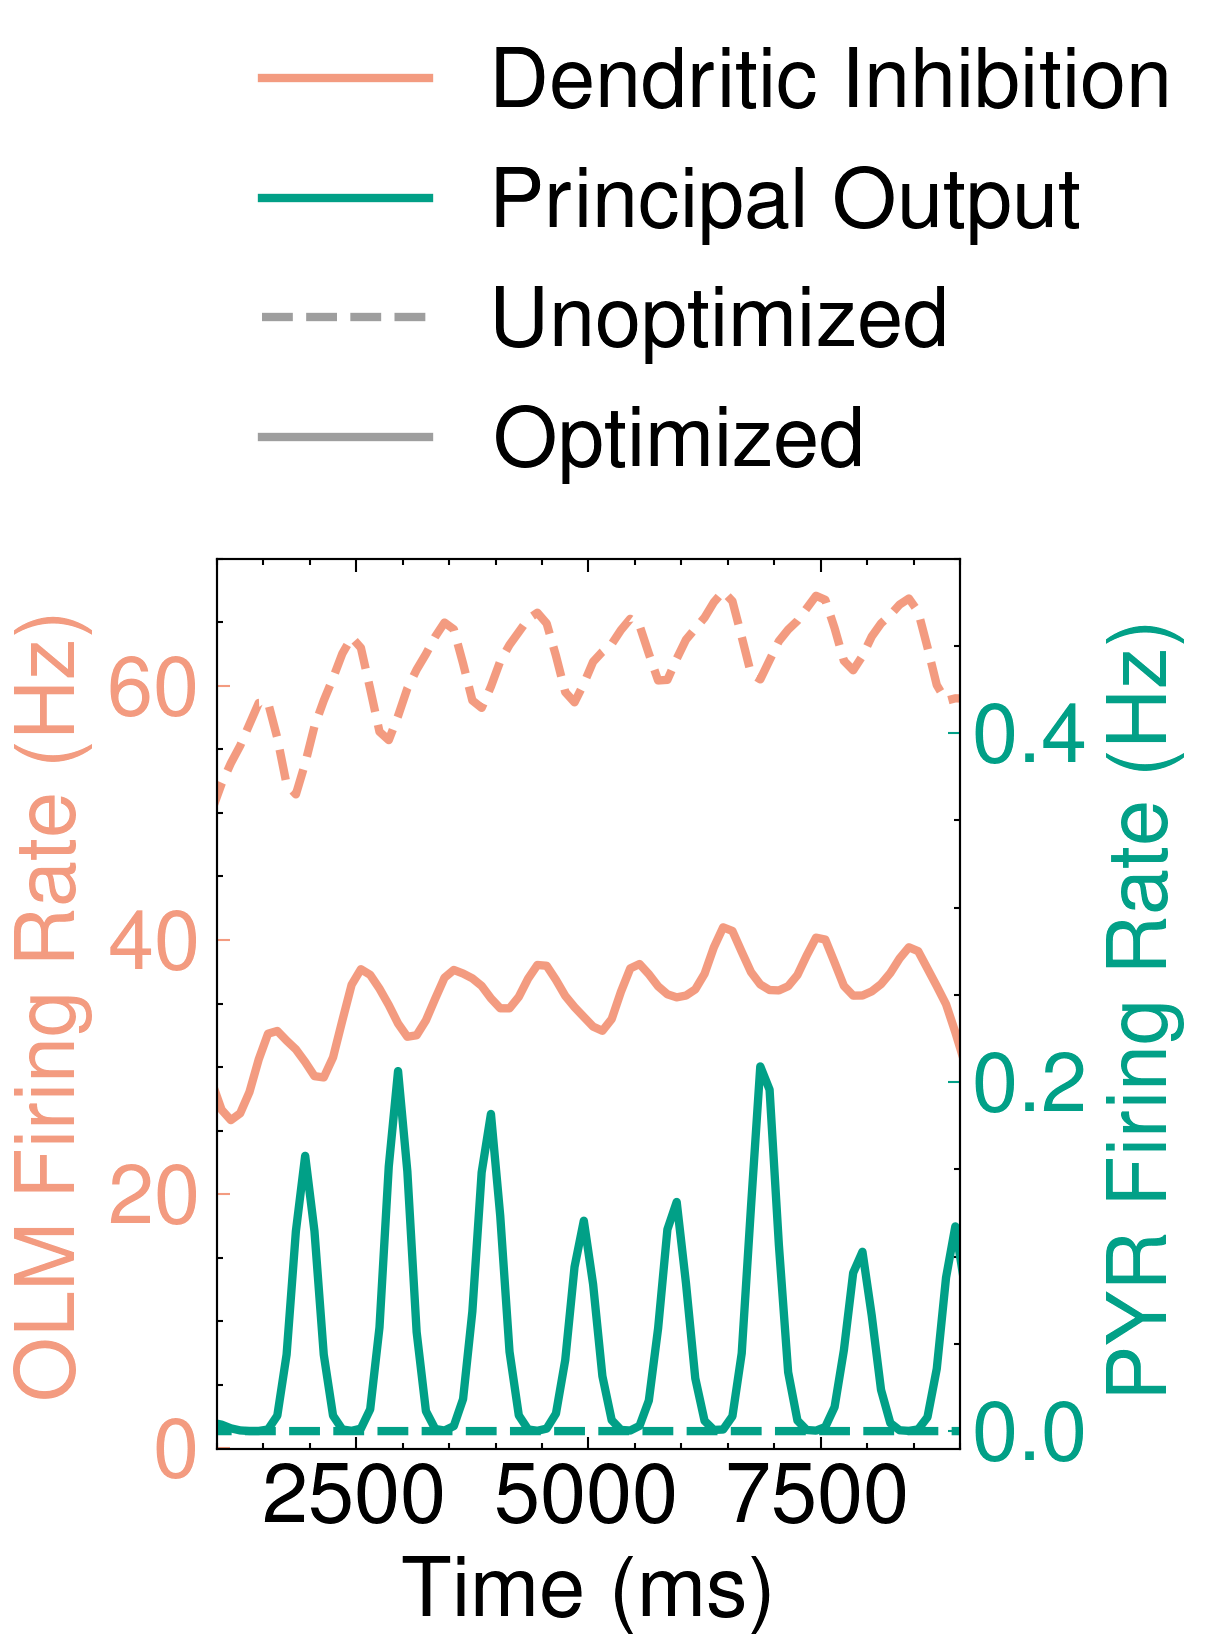

In [51]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

with rc_context():

    window_ms = 250
    bin_size = 100  # ms
    t_end = 9750
    time_bins = np.arange(0, t_end + bin_size, bin_size)
    time_centers = time_bins[:-1] + bin_size / 2

    fig, ax_left = plt.subplots(figsize=(4.5, 6))
    ax_right = ax_left.twinx()

    per_neuron_firing = {
        key: np.nan_to_num(
            np.mean(np.unique(val['i'], return_counts=True)[1] / (t_end / 100))
        )
        for key, val in ca1_culture_eval_data[point].items()
    }

    lines = []
    labels = []

    role_labels = {"PYR": "Principal Output", "OLM": "Dendritic Inhibition"}
    axis_map = {"OLM": ax_left, "PYR": ax_right}
    y_labels = {
        "OLM": "OLM Firing Rate (Hz)",
        "PYR": "PYR Firing Rate (Hz)" #"Smoothed Instantaneous Firing Rate (Hz)",
    }

    color4 = "#54bcd4"
    color3 = "#01a087"
    color2 ="#3c5488"
    color = '#f39b80'

    color_map = {"OLM": color, "PYR":color3}

    for pop_name in ["OLM", "PYR"]:
        for point in ['none', "opt"]:
            data = ca1_culture_eval_data[point].get(pop_name)
            if data is None:
                continue

            spike_times = data['t']
            neuron_ids = data['i']
            unique_neurons = np.unique(neuron_ids)
            n_neurons = len(unique_neurons)
            if n_neurons == 0:
                continue

            spike_counts, _ = np.histogram(spike_times, bins=time_bins)
            firing_rate = spike_counts / n_neurons / (bin_size / 1000.0)
            smoothed_rate = gaussian_filter1d(firing_rate, sigma=window_ms / bin_size / 2)

            axis = axis_map[pop_name]
            color = color_map[pop_name]
            label = f"{role_labels[pop_name]}"# ({pop_name})" 
            linestype = '-' if point == 'opt' else '--'

            #label += {'none': "Unoptimized", "opt": "Optimized"}[point]

            line, = axis.plot(time_centers, smoothed_rate, label=label, color=color, linestyle=linestype, linewidth=2)

        lines.append(line)
        labels.append(label)

        axis.set_ylabel(y_labels[pop_name], color=color)
        axis.tick_params(axis='y', colors=color)
        axis.set_xlim([1000, 9000])
        if pop_name == 'OLM':
            axis.set_ylim([-0.01, 70])
            pass
        elif pop_name == 'PYR':
            axis.set_ylim([-0.01, 0.5])

        

    ax_left.set_xlabel('Time (ms)')
    #ax_left.set_title('Smoothed Instantaneous Firing Rate')

    grey_color = colors.get('grey', '#9e9e9e')
    legend_unopt = ax_left.plot([], [], color=grey_color, linestyle='--', linewidth=2)[0]
    legend_opt = ax_left.plot([], [], color=grey_color, linestyle='-', linewidth=2)[0]
    lines.extend([legend_unopt, legend_opt])
    labels.extend(['Unoptimized', 'Optimized'])

    ax_left.legend(lines, labels, bbox_to_anchor=(-0.04, 1.))

    fig.tight_layout()
    plt.show()

    


In [52]:
stash("figure5/population-firing", fig)

## HV Optimization trajectory 

In [ ]:
_ca1_culture = get("interface._ca1_culture")

# for c in _ca1_culture.components:
#     c.cached(True)

components = list(_ca1_culture.components.filter(lambda x: x.cached()))
if not components:
    raise RuntimeError("No cached CA1 culture components found")

# components = components + [get("interface._ca1_culture_baseline").launch()]

reference_experiment = components[0]
firing_rate_indices = [
    idx
    for idx, name in enumerate(reference_experiment.objective_names)
    if "firing rate" in name.lower()
]
firing_rate_names = [
    reference_experiment.objective_names[idx] for idx in firing_rate_indices
]

component_data = {component.uuid: component.load_h5() for component in components}

# pre-compute the nadir using only firing rate objectives
global_nadir = (
    pd.concat(
        [
            data["objectives"].iloc[:, firing_rate_indices].dropna()
            for data in component_data.values()
        ]
    )
    .max()
    .to_list()
)

#print("firing rate objectives:", firing_rate_names, flush=True)

ca1_culture_hvs = {}

for experiment in components:
    model_name = (
        f"{experiment.label()}-{experiment.config.dopt_params.population_size}".replace(
            "miv_simulator.optimize_network::O:", ""
        )
    )
    #print(model_name, experiment.uuid)
    # continue
    epoch_ranges = experiment.epoch_ranges(from_zero=True)
    ca1_culture_hvs.setdefault(model_name, {})
    data = component_data[experiment.uuid]
    objectives = data["objectives"].iloc[:, firing_rate_indices]
    epochs = data["epochs"]
    for epoch, region in enumerate(epoch_ranges[:50]):  # 50
        #print(model_name, epoch, region, flush=True)
        ca1_culture_hvs[model_name].setdefault(epoch, [])

        if region is None:
            region_slice = slice(None)
        else:
            region_slice = slice(*region)

        pf_df = objectives.iloc[region_slice]
        region_epochs = epochs[region_slice]
        valid = ~np.any(np.isnan(pf_df.to_numpy()), axis=1)
        pf_df = pf_df.iloc[valid]
        if pf_df.empty:
            continue

        hv = experiment.norm_hv(global_nadir, pf=pf_df.to_numpy().tolist())
        #print(hv)
        ca1_culture_hvs[model_name][epoch].append(hv)



numprocs=1


2025-12-12 14:46:17.030318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-12 14:46:17.051297: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-12 14:46:17.051330: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-12 14:46:17.064649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-12 14:46:18.128356: W tensorflow/compiler/tf

firing rate objectives: ['PYR firing rate', 'CCKBC firing rate', 'BS firing rate', 'AAC firing rate', 'PVBC firing rate', 'IS1 firing rate', 'IS2 firing rate', 'IS3 firing rate', 'OLM firing rate', 'IVY firing rate', 'NGFC firing rate', 'SCA firing rate']


In [54]:
stash('figure5-ca1_culture_hvs', ca1_culture_hvs)

In [5]:
ca1_culture_hvs = restore('figure5-ca1_culture_hvs')
ca1_culture_hvs = {
    k: {int(kk): vv for kk, vv in v.items()} for k, v in ca1_culture_hvs.items()
}

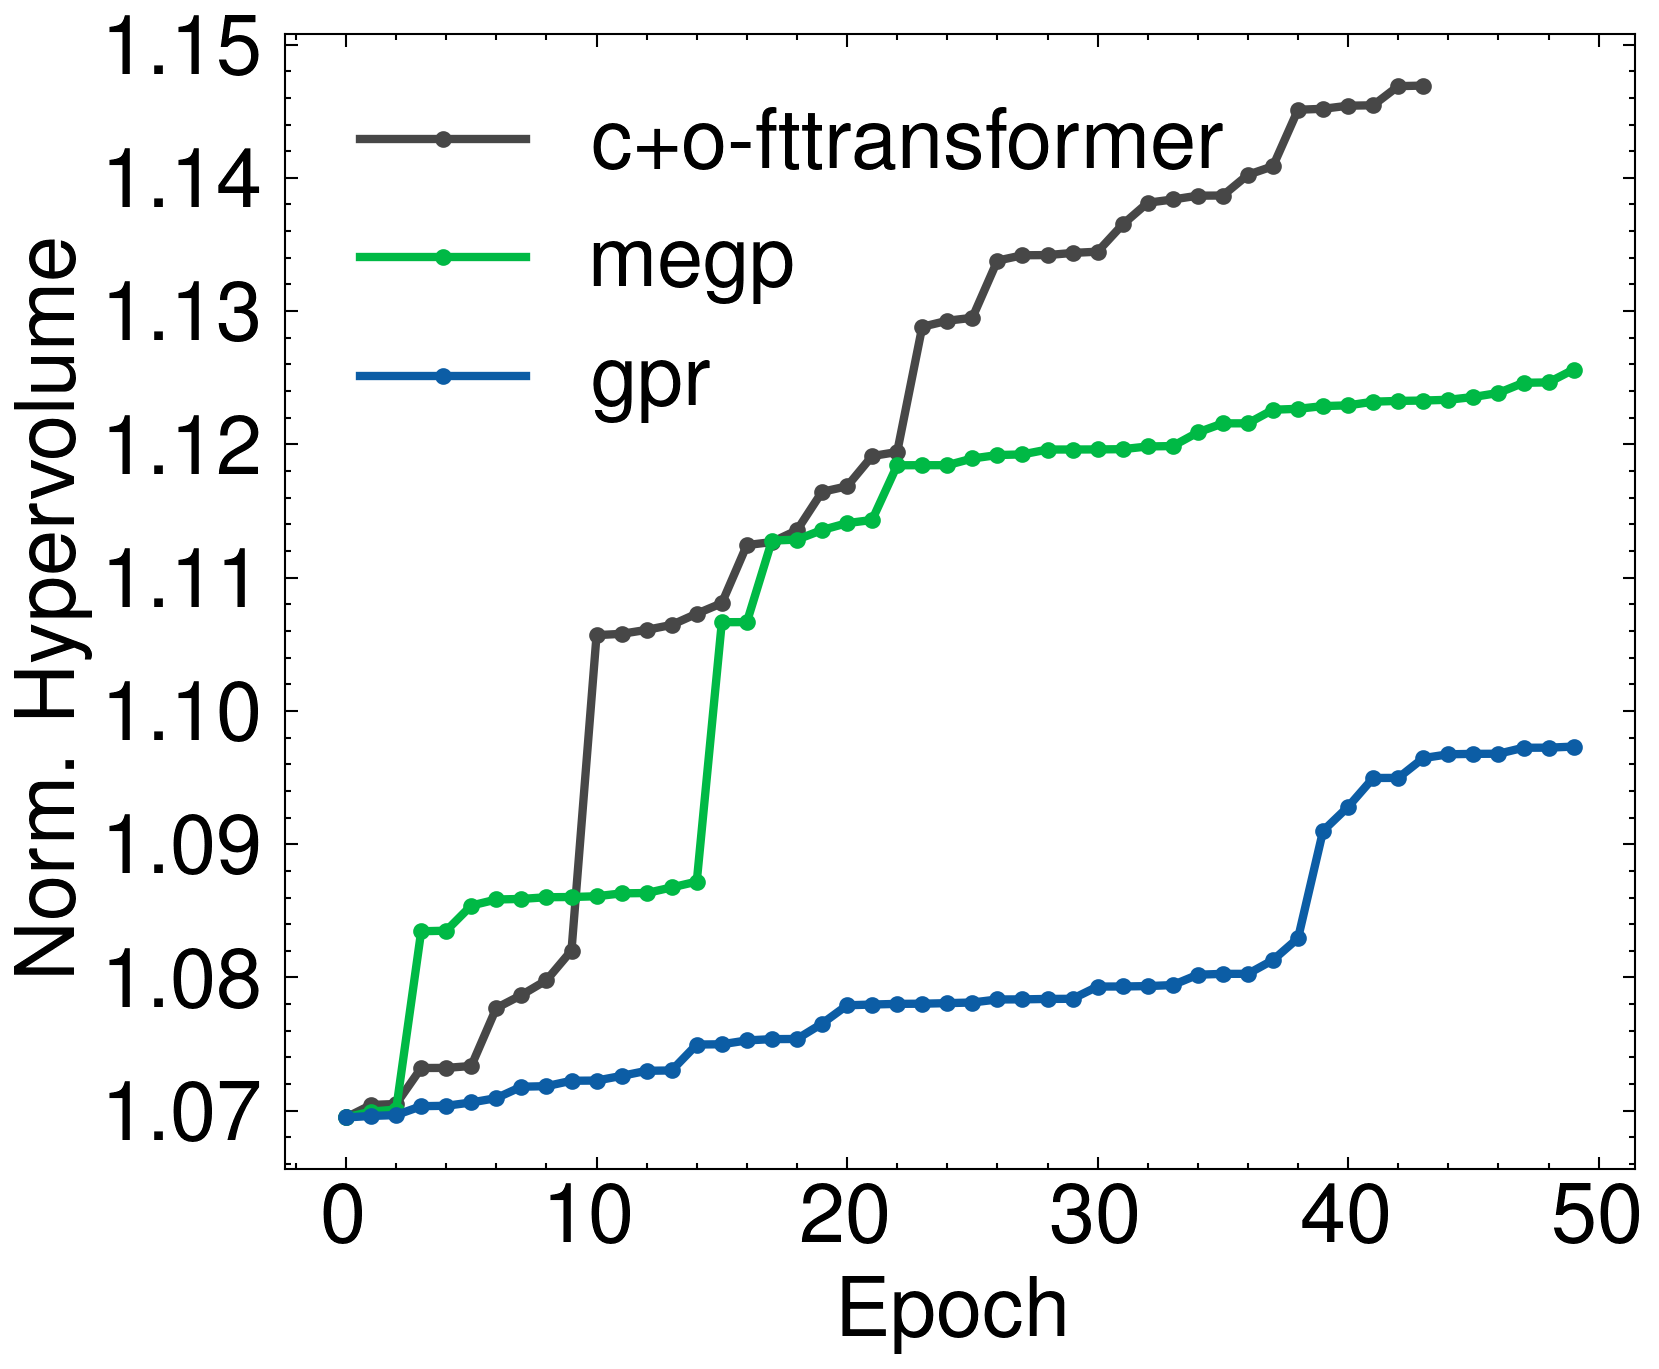

In [9]:
with rc_context():
    fig = plt.figure(figsize=(6,5))
    for model_name, epoch_data in sorted(ca1_culture_hvs.items(), reverse=True, key=lambda x: np.mean(x[1][40])):
        epochs = []
        mean_hvs = []
        for epoch in sorted(epoch_data):
            values = epoch_data[epoch]
            if not values:
                continue
            epochs.append(epoch)
            mean_hvs.append(float(np.mean(values)))
        if not epochs:
            continue

        label = model_name.split('/')[0].replace('joint-c+o', 'c+o-fttransformer')
        color = mcolors[label]

        plt.plot(epochs, mean_hvs, marker="o", label=label,color=color, linewidth=2 )


    plt.xlabel("Epoch")
    plt.ylabel("Norm. Hypervolume")
    #plt.title("CA1 culture hypervolume per epoch")
    plt.legend()
    # plt.yscale("log")
    plt.tight_layout()
plt.show()

In [24]:
stash('figure5/hv-network', fig)

# Time and compute saving

In [6]:
gpr_best = ca1_culture_hvs['gpr/C:-/S:--100'][49][0]
megp_best = ca1_culture_hvs['megp/C:-/S:--100'][49][0]

# when do we reach that?
baseline = ca1_culture_hvs['joint-c+o/C:-/S:joint-c+o[-]-100']

epoch_saving = {}

for epoch, hvs in baseline.items():
    hv = hvs[0]
    if hv >= gpr_best and 'gpr' not in epoch_saving:
        epoch_saving['gpr'] = 49 - epoch

    if hv >= megp_best and 'megp' not in epoch_saving:
        epoch_saving['megp'] = 49 - epoch

epoch_saving

{'gpr': 39, 'megp': 26}

In [7]:
from uncertainties import ufloat

timing_metrics = restore('figure2-timing_metrics')
stats = restore('figure5-timing-stats')
eval_time = ufloat(np.mean(stats['ran simulation']), np.std(stats['ran simulation']))

tt = {}

for p, d in timing_metrics.items():
    for model, dd in d.items():
        tt.setdefault(model, {})
        for v, ddd in dd.items():
            tt[model].setdefault(v, [])
            tt[model][v] += ddd
        for k in [kk for kk in tt[model].keys() if 'u' not in kk]:
            tt[model][f"{k}_mean"] = np.mean(tt[model][k])
            tt[model][f"{k}_std"] = np.std(tt[model][k])
            tt[model][f"{k}_u"] = ufloat(tt[model][f"{k}_mean"], tt[model][f"{k}_std"])

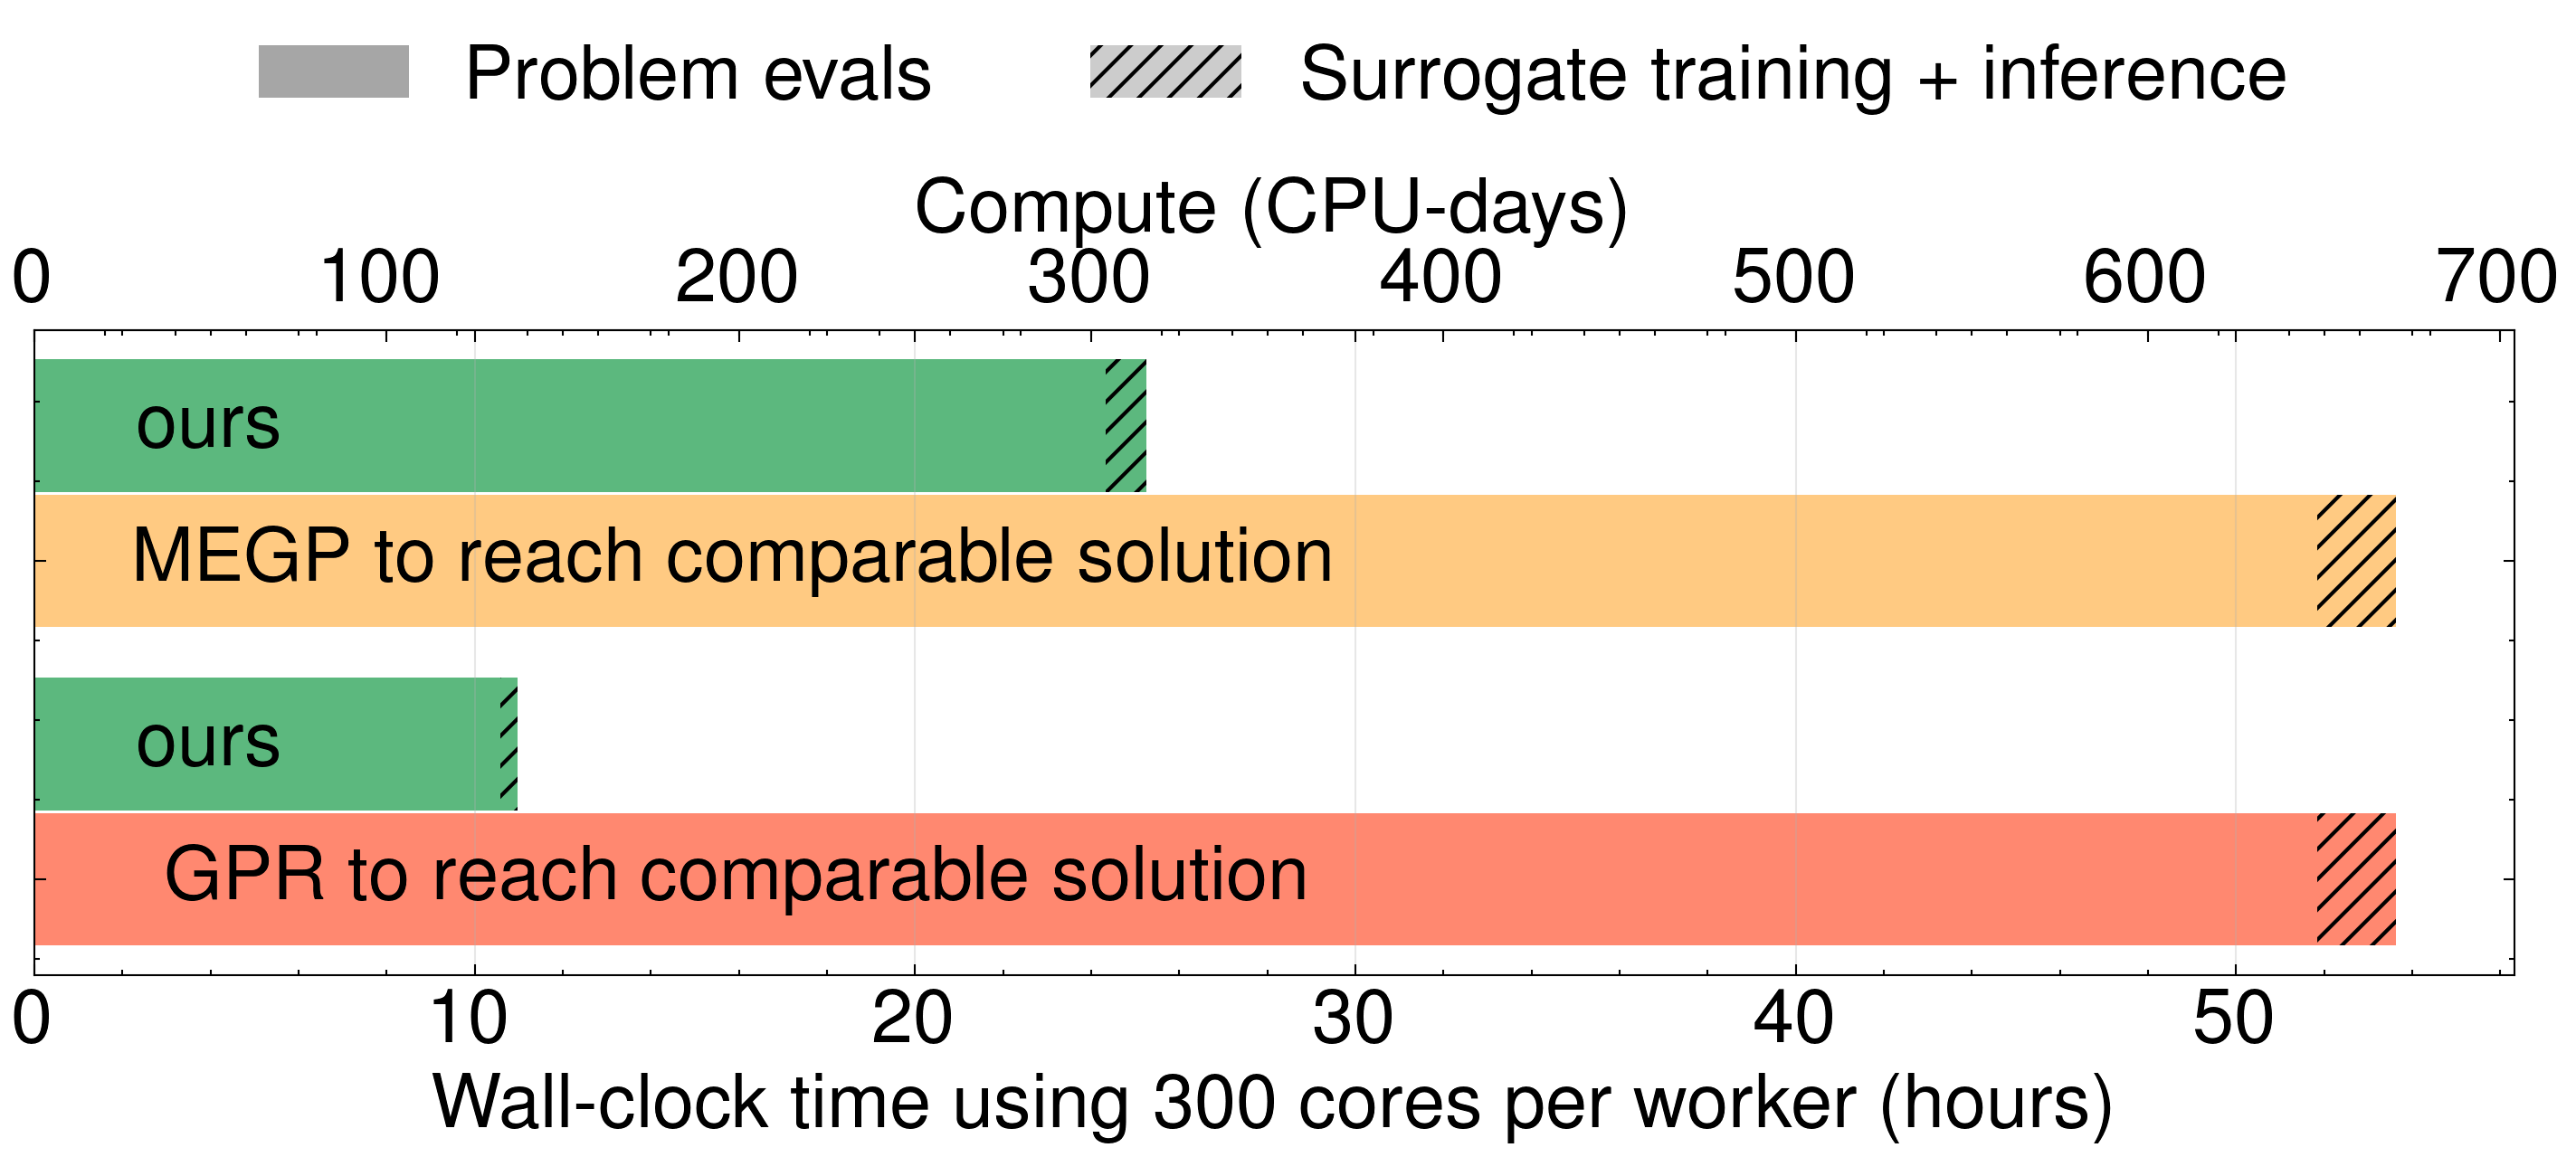

In [50]:
from matplotlib.patches import Patch

with rc_context():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = ['gpr', 'megp']
    y_pos = np.arange(len(models))
    y_pos = [0, 1.2]
    bar_height = 0.5

    baseline_sopt_fit = ufloat(tt['fttransformer-c+o']['fit_mean'], tt['fttransformer-c+o']['fit_std'])
    baseline_sopt_predict = ufloat(tt['fttransformer-c+o']['predict_mean'], tt['fttransformer-c+o']['predict_std'])
   
    qcolors = {
        'megp': "#ffb44d",
        'gpr': '#ff5633',
        'baseline': '#179a48'
    }
    
    for idx, model in enumerate(models):
        saved = 49 # - epoch_saving[model]
        
        sopt_fit = ufloat(tt['megp']['fit_mean'], tt['megp']['fit_std'])
        sopt_predict = ufloat(tt['megp']['predict_mean'], tt['megp']['predict_std'])
        
        total_eval_time = saved * eval_time
        total_sopt_fit_time = saved * sopt_fit
        total_sopt_predict_time = saved * sopt_predict
        total_time = (total_eval_time + total_sopt_fit_time + total_sopt_predict_time) / (60*60)
        
        eval_hours = float(total_eval_time.nominal_value) / (60*60)
        fit_hours = float(total_sopt_fit_time.nominal_value) / (60*60)
        predict_hours = float(total_sopt_predict_time.nominal_value) / (60*60)
        
        ax.barh(y_pos[idx], eval_hours, bar_height,
                label='Problem evaluation' if idx == 0 else '', 
                color=qcolors[model], alpha=0.7)
        #ax.barh(y_pos[idx], fit_hours, bar_height, left=eval_hours, label='Fit' if idx == 0 else '', color='#00B945', alpha=0.7)
        ax.barh(y_pos[idx], predict_hours + fit_hours, bar_height, left=eval_hours, 
                label='Surrogate training + inference' if idx == 0 else '', 
                color=qcolors[model], hatch='///', alpha=0.7)

        ax.text(16, y_pos[idx] - 0.0*bar_height, model.upper() + " to reach comparable solution", 
                ha='center', va='center', fontweight='bold', fontsize=20, color='black')


        # baseline
        baseline_epochs = 49 - epoch_saving[model]
        baseline_total_eval_time = baseline_epochs * eval_time
        baseline_total_sopt_fit_time = baseline_epochs * baseline_sopt_fit
        baseline_total_sopt_predict_time = baseline_epochs * baseline_sopt_predict
        baseline_total_time = (baseline_total_eval_time + baseline_total_sopt_fit_time + baseline_total_sopt_predict_time) / (60*60)

        baseline_eval_hours = float(baseline_total_eval_time.nominal_value) / (60*60)
        baseline_fit_hours = float(baseline_total_sopt_fit_time.nominal_value) / (60*60)
        baseline_predict_hours = float(baseline_total_sopt_predict_time.nominal_value) / (60*60)

        ax.barh(y_pos[idx] + bar_height + 0.01, baseline_eval_hours, bar_height,
            label='Baseline problem evaluation' if idx == 0 else '', 
            color=qcolors['baseline'], alpha=0.7)
        ax.barh(y_pos[idx] + bar_height + 0.01, baseline_predict_hours + baseline_fit_hours, bar_height, 
            left=baseline_eval_hours, 
            label='Baseline surrogate training + inference' if idx == 0 else '', 
            color=qcolors['baseline'], hatch='///', alpha=0.7)

        ax.text(4, y_pos[idx] + bar_height, "ours", ha='center', va='center', fontweight='bold', fontsize=20, color='black')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([]) #["vs. gpr", 'vs. megp'])#models)
    ax.set_xlabel('Wall-clock time using 300 cores per worker (hours)')
    #ax.set_xlim([0, 48])

    secax = ax.secondary_xaxis(
        "top",
        functions=(
            lambda x: x *300 / 24,
            lambda x: x / 300 * 24,
        ),
    )
    secax.set_xlabel("Compute (CPU-days)")

    ax.legend(handles=[
        Patch(facecolor='gray', label='Problem evals', alpha=0.7),
        Patch(facecolor='gray', label='Surrogate training + inference', alpha=0.4, hatch='///')
        ],
        loc='upper center', bbox_to_anchor=(0.5, 1.55), ncol=2, frameon=False)
    ax.grid(axis='x', alpha=0.3)
    
    fig.tight_layout()
    plt.show()

In [51]:
stash('figure5/compute-savings-absolute', fig)

# Relative saving

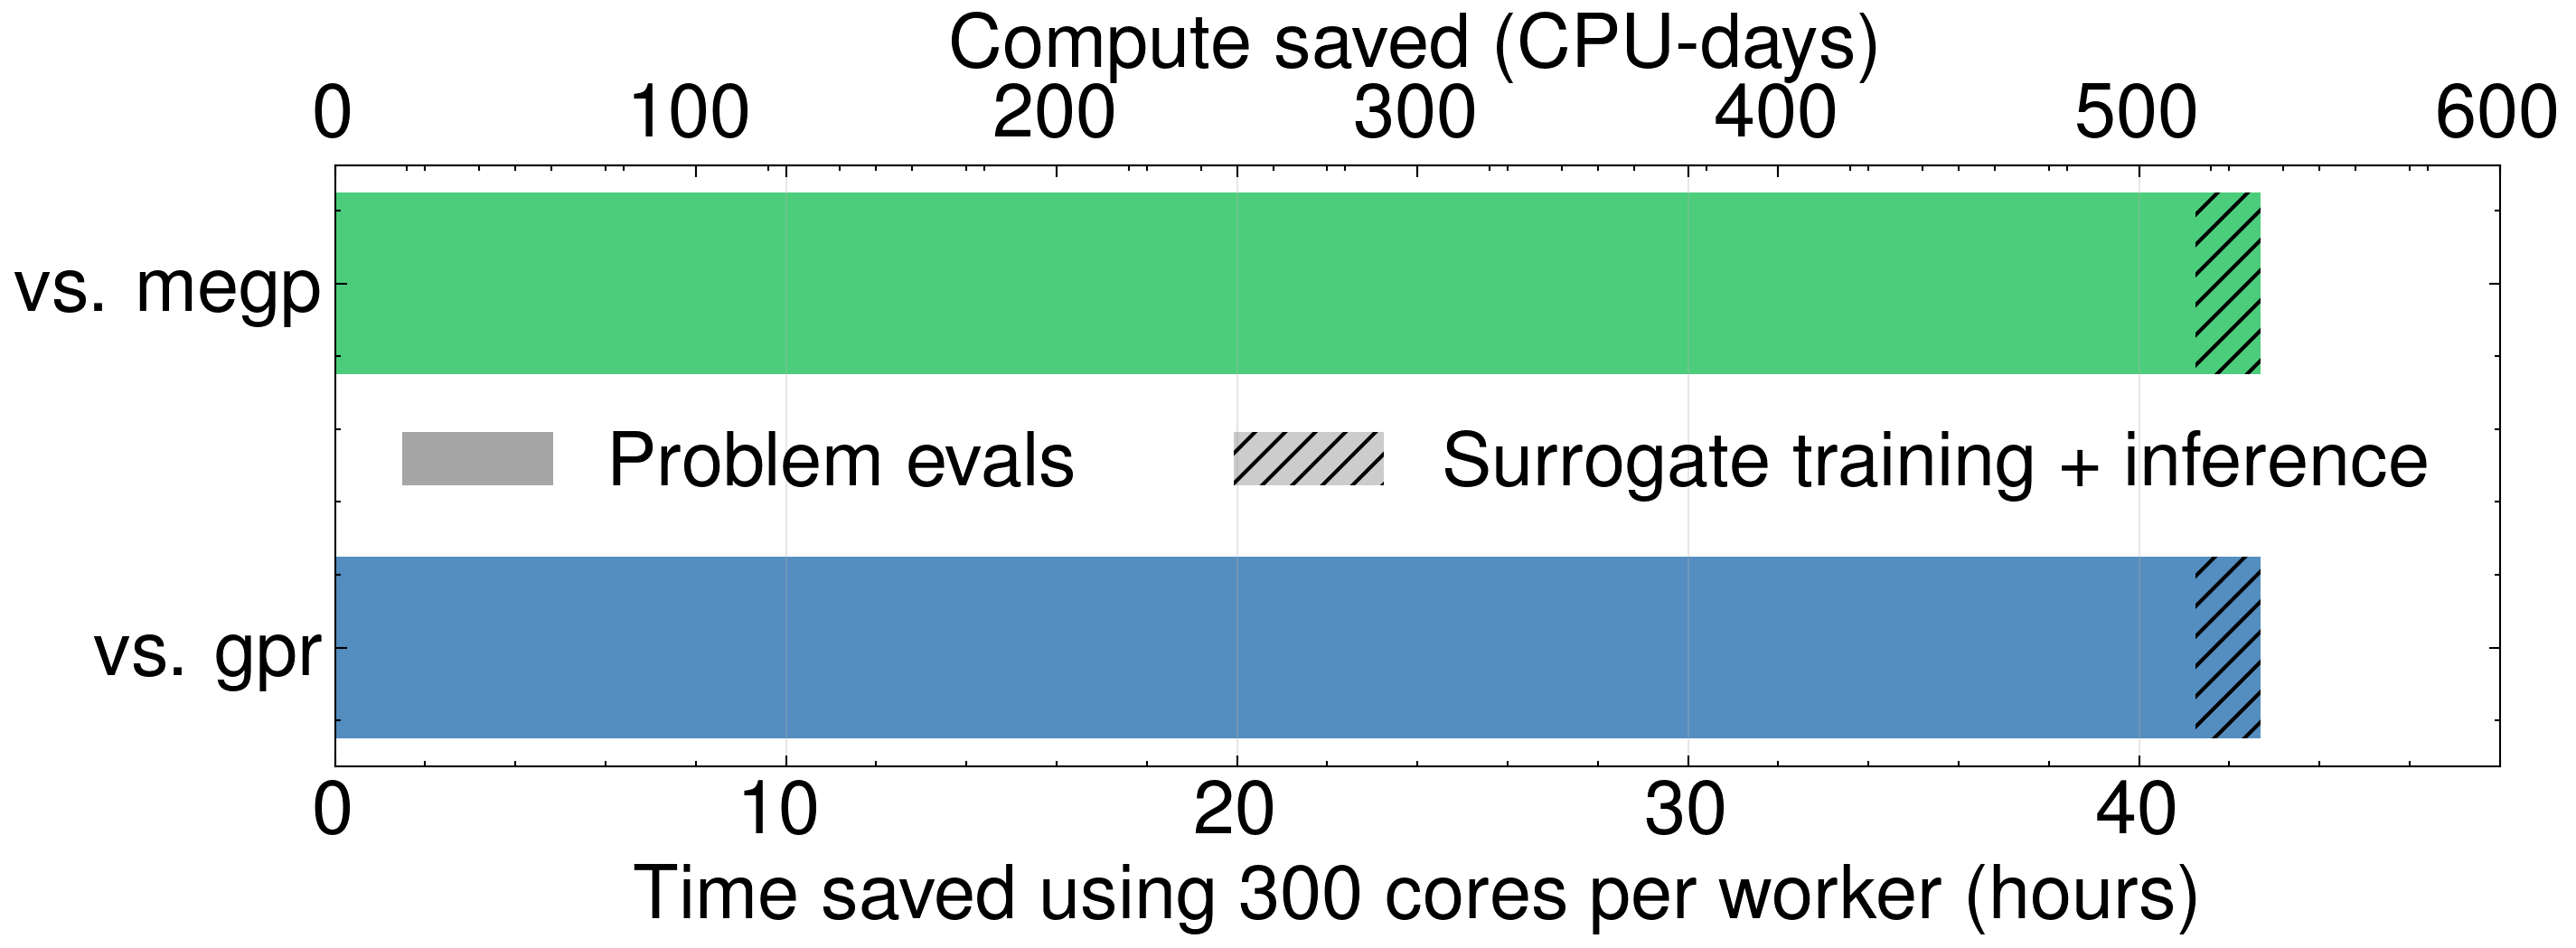

In [10]:
from matplotlib.patches import Patch

with rc_context():
    fig, ax = plt.subplots(figsize=(10, 4))
    
    models = ['gpr', 'megp']
    y_pos = np.arange(len(models))
    bar_height = 0.5
    
    for idx, model in enumerate(models):
        epochs_required = epoch_saving[model]
        
        sopt_fit = ufloat(tt['megp']['fit_mean'], tt['megp']['fit_std'])
        sopt_predict = ufloat(tt['megp']['predict_mean'], tt['megp']['predict_std'])
        
        total_eval_time = saved * eval_time
        total_sopt_fit_time = saved * sopt_fit
        total_sopt_predict_time = saved * sopt_predict
        total_time = (total_eval_time + total_sopt_fit_time + total_sopt_predict_time) / (60*60)
        
        eval_hours = float(total_eval_time.nominal_value) / (60*60)
        fit_hours = float(total_sopt_fit_time.nominal_value) / (60*60)
        predict_hours = float(total_sopt_predict_time.nominal_value) / (60*60)
        
        ax.barh(y_pos[idx], eval_hours, bar_height,
                label='Problem evaluation' if idx == 0 else '', 
                color=mcolors[model], alpha=0.7)
        #ax.barh(y_pos[idx], fit_hours, bar_height, left=eval_hours, label='Fit' if idx == 0 else '', color='#00B945', alpha=0.7)
        ax.barh(y_pos[idx], predict_hours + fit_hours, bar_height, left=eval_hours, 
                label='Surrogate training + inference' if idx == 0 else '', 
                color=mcolors[model], hatch='///', alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(["vs. gpr", 'vs. megp'])#models)
    ax.set_xlabel('Time saved using 300 cores per worker (hours)')
    ax.set_xlim([0, 48])

    secax = ax.secondary_xaxis(
        "top",
        functions=(
            lambda x: x *300 / 24,
            lambda x: x / 300 * 24,
        ),
    )
    secax.set_xlabel("Compute saved (CPU-days)")

    ax.legend(handles=[
        Patch(facecolor='gray', label='Problem evals', alpha=0.7),
        Patch(facecolor='gray', label='Surrogate training + inference', alpha=0.4, hatch='///')
        ],
        loc='center right', ncol=2)
    ax.grid(axis='x', alpha=0.3)
    
    fig.tight_layout()
    plt.show()

In [78]:
stash('figure5/compute-savings', fig)

# Target predictions

In [6]:
_ca1_culture = get("interface._ca1_culture")

In [7]:
targets = {}

for k, v in _ca1_culture.components[0].config.dopt_params.obj_fun_init_args.opt_targets.items():
    if 'firing rate' not in k:
        continue

    targets[k.replace(' firing rate', '')] = v

targets

numprocs=1


2025-12-15 21:39:47.346984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-15 21:39:47.367254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-15 21:39:47.367292: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-15 21:39:47.380642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 21:39:48.540877: W tensorflow/compiler/tf

{'AAC': 18.0,
 'BS': 18.0,
 'CCKBC': 9.0,
 'IS1': 17.0,
 'IS2': 17.0,
 'IS3': 17.0,
 'IVY': 3.0,
 'NGFC': 7.4,
 'OLM': 13.0,
 'PVBC': 18.0,
 'PYR': 2.0,
 'SCA': 9.0}

In [10]:
ca1_culture_best_features = {}

for c in _ca1_culture.components:
    name = c.mO

    #region = c.epoch_ranges(from_zero=True)
    #raise ValueError(region[50])
    best = c.get_best(region=[0, 650])
    pareto_front = best['y']

    pareto_front = pareto_front[[col for col in pareto_front.columns if 'firing rate' in col]]
    best_idx = pareto_front.max(axis=1).idxmax()

    solution = best['f'].iloc[-1]
    ca1_culture_best_features[name] = {}
    for k in targets:
        ca1_culture_best_features[name][k] = float(solution[f"{k} firing rate"])

ca1_culture_best_features

{'gpr': {'AAC': 25.543949127197266,
  'BS': 4.047196388244629,
  'CCKBC': 35.28401565551758,
  'IS1': 85.54219818115234,
  'IS2': 73.61076354980469,
  'IS3': 64.17351531982422,
  'IVY': 57.99105453491211,
  'NGFC': 40.84843444824219,
  'OLM': 66.2201919555664,
  'PVBC': 0.4389091432094574,
  'PYR': 0.25576791167259216,
  'SCA': 3.6477506160736084},
 'megp': {'AAC': 16.907695770263672,
  'BS': 0.3987867534160614,
  'CCKBC': 2.630009889602661,
  'IS1': 60.46598815917969,
  'IS2': 13.203721046447754,
  'IS3': 86.64990997314453,
  'IVY': 77.01117706298828,
  'NGFC': 40.206687927246094,
  'OLM': 59.03704071044922,
  'PVBC': 50.599700927734375,
  'PYR': 0.2451246827840805,
  'SCA': 0.7654589414596558},
 'joint-c+o': {'AAC': 8.155779838562012,
  'BS': 1.075130820274353,
  'CCKBC': 37.51069641113281,
  'IS1': 63.681941986083984,
  'IS2': 4.572910785675049,
  'IS3': 51.41071701049805,
  'IVY': 65.36458587646484,
  'NGFC': 48.12896728515625,
  'OLM': 36.795654296875,
  'PVBC': 39.59162521362305,

In [11]:
stash('figure5-ca1_culture_best_features', ca1_culture_best_features)
stash('figure5-targets', targets)

In [2]:
ca1_culture_best_features = restore('figure5-ca1_culture_best_features')
targets = restore('figure5-targets')

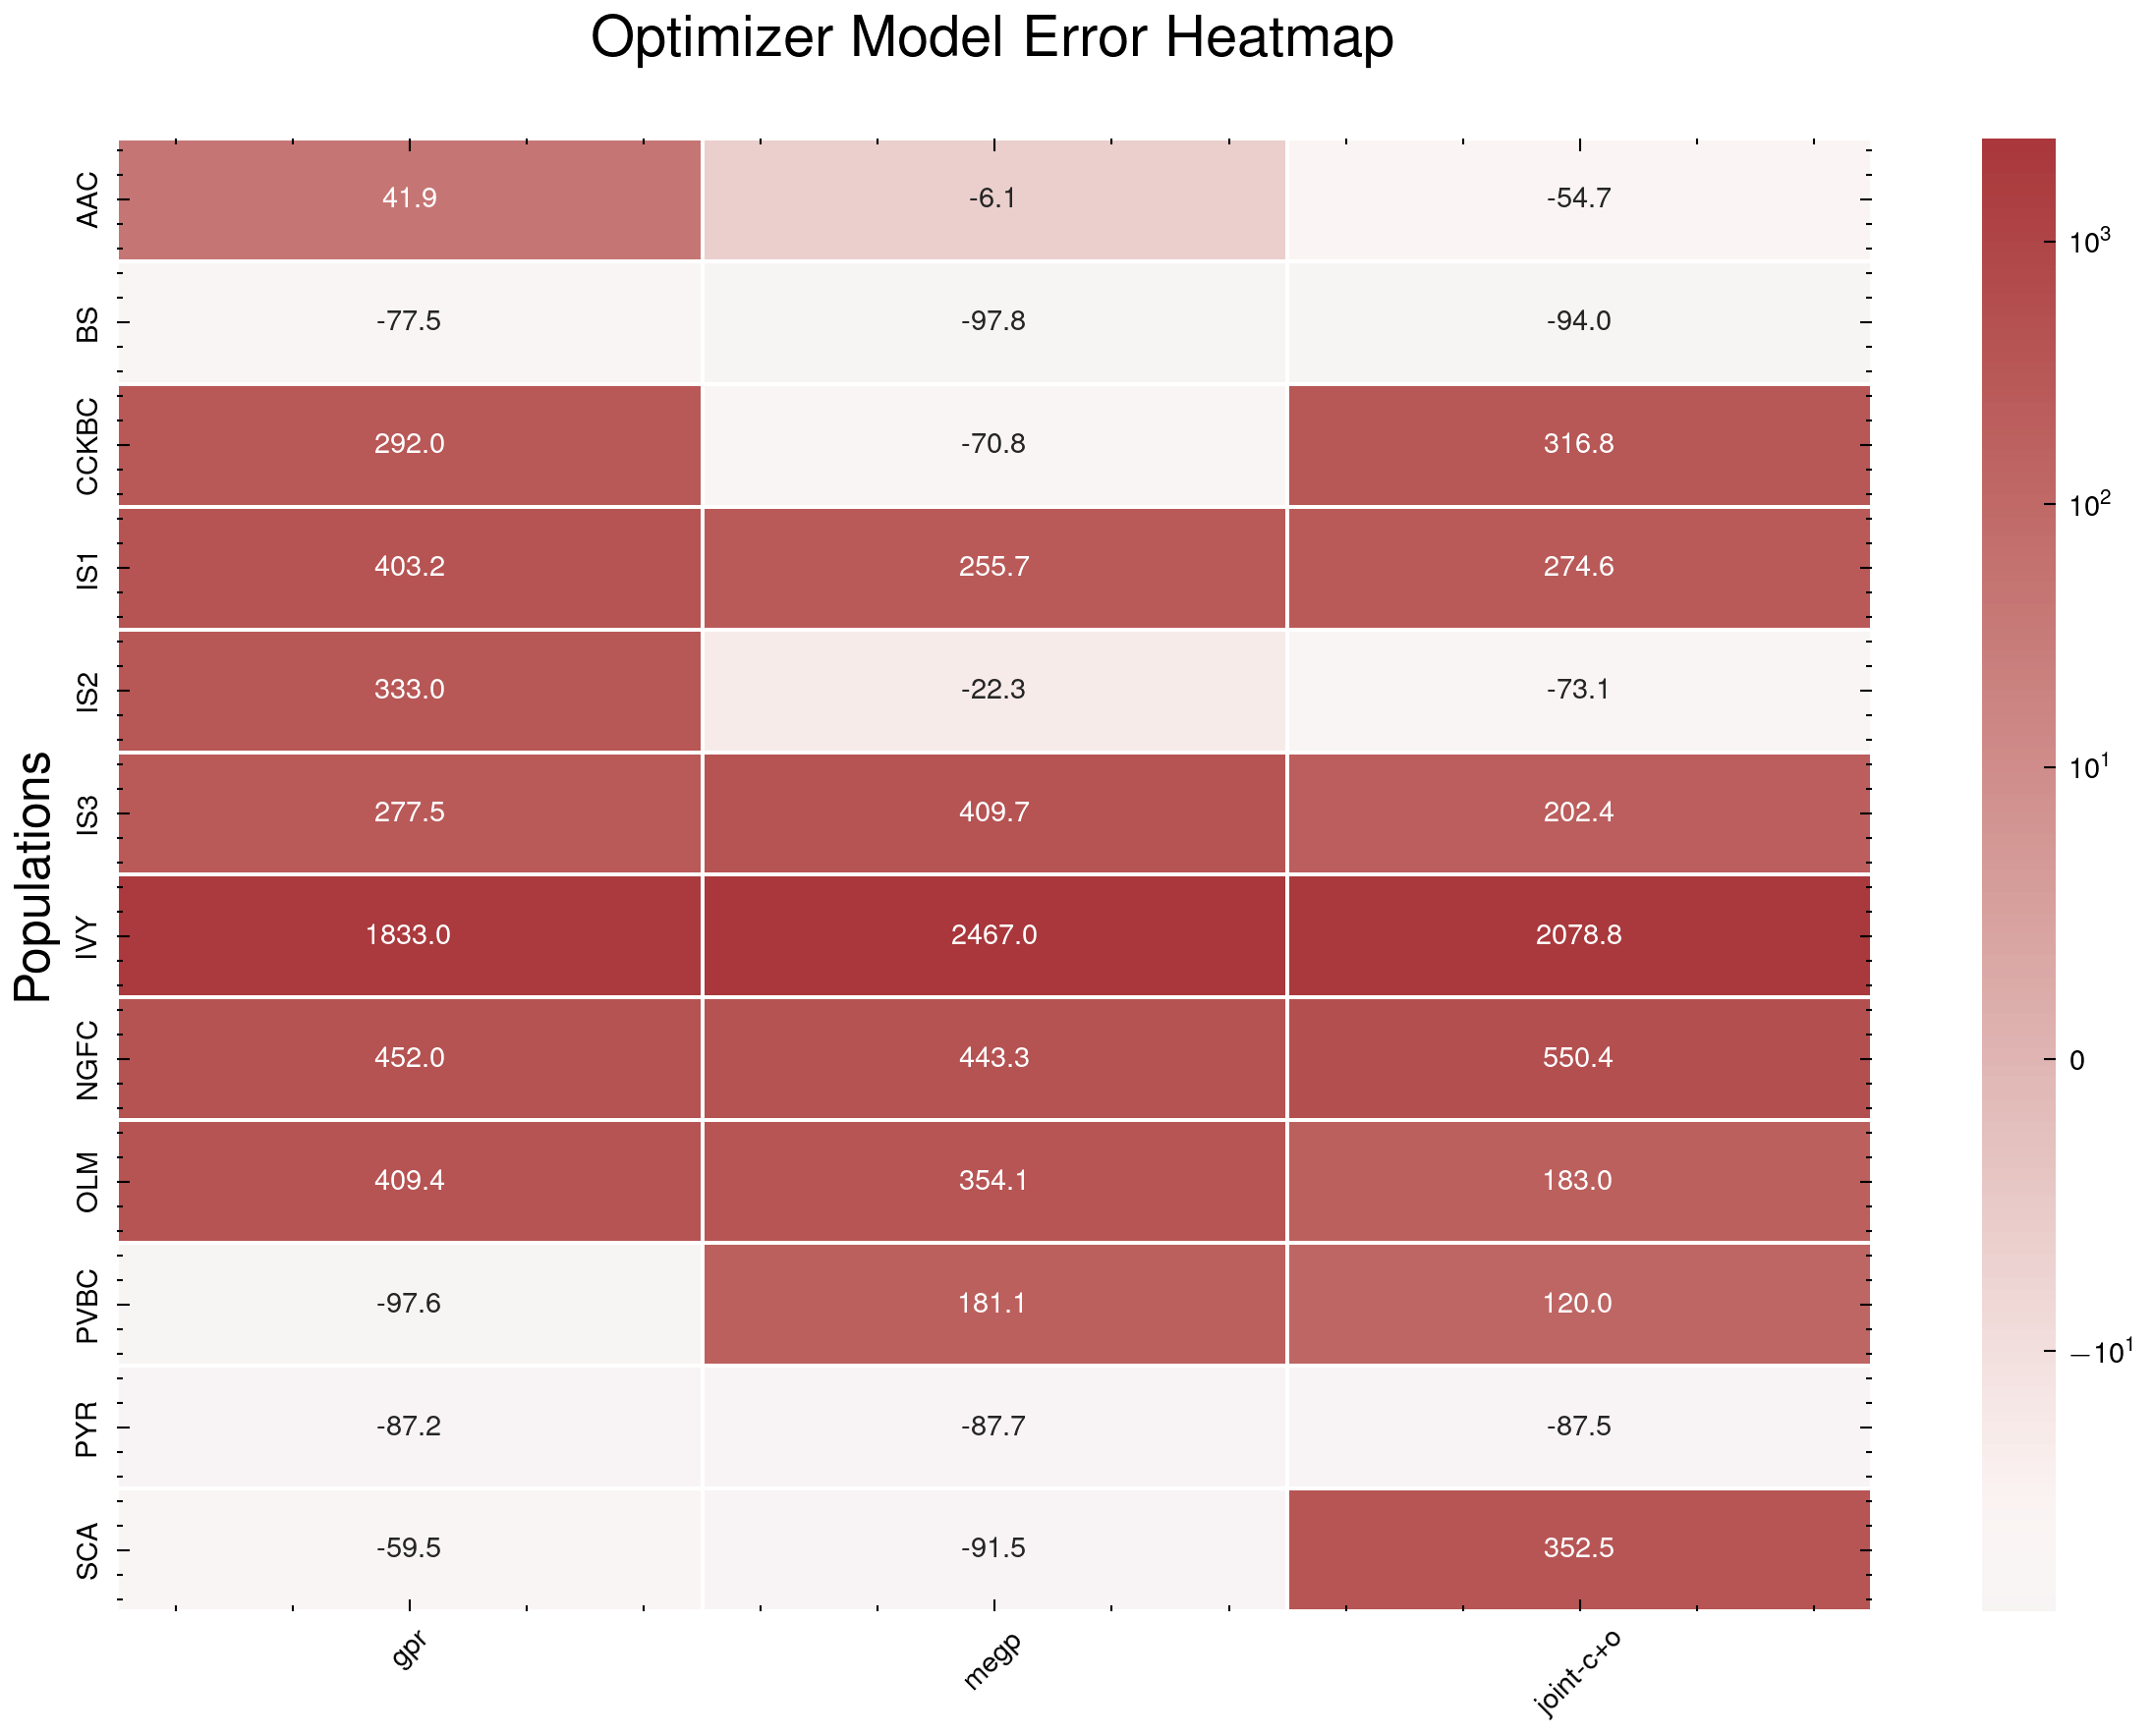

In [5]:
import seaborn as sns
from matplotlib.colors import SymLogNorm

df_models = pd.DataFrame(ca1_culture_best_features)

target_series = pd.Series(targets)

df_error = df_models.sub(target_series, axis=0).div(target_series, axis=0) * 100

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    df_error, 
    annot=True,
    fmt=".1f",
    cmap="vlag",
    norm=SymLogNorm(linthresh=10, linscale=1, vmin=df_error.min().min(), vmax=df_error.max().max()),
    center=0,
    linewidths=.5,
    cbar_kws={'label': '% Deviation from Target'}
)

plt.title('Optimizer Model Error Heatmap', fontsize=14, pad=20)
plt.ylabel('Populations', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

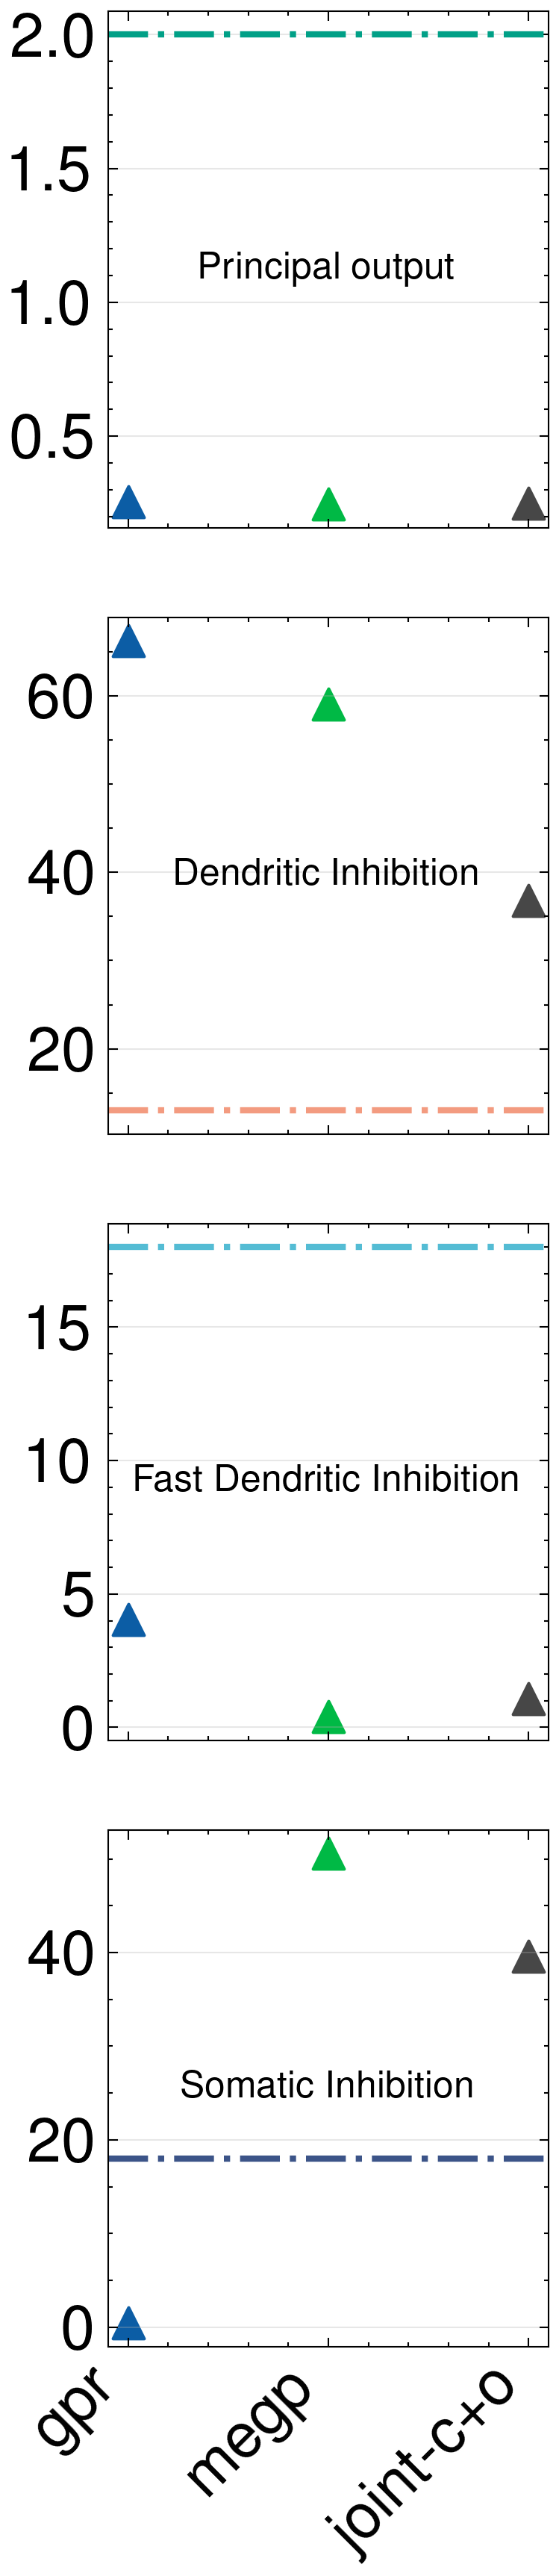

In [4]:
with rc_context():

    selection = {
        'PYR': "Principal output",
        "OLM": "Dendritic Inhibition",
        "BS": "Fast Dendritic Inhibition",
        "PVBC": "Somatic Inhibition",
    }


    fig, axes = plt.subplots(len(selection), 1, figsize=(3, 12), sharex=False)
    plt.subplots_adjust(hspace=0.)
    
    


    # Prepare data
    populations = list(selection.keys())
    model_names = list(ca1_culture_best_features.keys())

    colors_list = ["#0C5DA5", "#00B945", "#474747"]
    
    for idx, pop in enumerate(populations):
        ax = axes[idx]
        
        target = targets[pop]
        
        model_values = [ca1_culture_best_features[model_name][pop] for model_name in model_names]
        
        x_positions = range(len(model_names))
        for i, (model_name, value) in enumerate(zip(model_names, model_values)):
            ax.scatter(i, value, s=100, color=colors_list[i], marker="^", label=model_name if idx == 0 else "")

        
        ax.axhline(target, color=
                   {2: "#54bcd4",
                    0: "#01a087",
                    3: "#3c5488",
                    1: '#f39b80'}[idx], 
                   linestyle='-.', 
                   linewidth=2, label='Target' if idx == 0 else "")
        
        ax.set_xticks(x_positions)
        if idx == len(populations) - 1:
            ax.set_xticklabels(model_names, rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
        #ax.set_title(f'{selection[pop]}')
        ax.grid(axis='y', alpha=0.3)

        ax.text(0.5, 0.5, selection[pop], 
            transform=ax.transAxes, 
            ha='center', va='center',
            fontsize=12, fontweight='bold')
        
        #ax.set_ylabel('Firing Rate (Hz)')
        #ax.legend(loc='best')
    
    fig.tight_layout()
    plt.show()

        Model Metric      Value  Target        Metric_Display  Deviation  \
0         gpr     BS   4.047196    18.0   Fast Dendritic Inh. -13.952804   
1         gpr    OLM  66.220192    13.0  Dendritic Inhibition  53.220192   
2         gpr   PVBC   0.438909    18.0    Somatic Inhibition -17.561091   
3         gpr    PYR   0.255768     2.0      Principal output  -1.744232   
4        megp     BS   0.398787    18.0   Fast Dendritic Inh. -17.601213   
5        megp    OLM  59.037041    13.0  Dendritic Inhibition  46.037041   
6        megp   PVBC  50.599701    18.0    Somatic Inhibition  32.599701   
7        megp    PYR   0.245125     2.0      Principal output  -1.754875   
8   joint-c+o     BS   1.075131    18.0   Fast Dendritic Inh. -16.924869   
9   joint-c+o    OLM  36.795654    13.0  Dendritic Inhibition  23.795654   
10  joint-c+o   PVBC  39.591625    18.0    Somatic Inhibition  21.591625   
11  joint-c+o    PYR   0.250383     2.0      Principal output  -1.749617   

    RelDevi

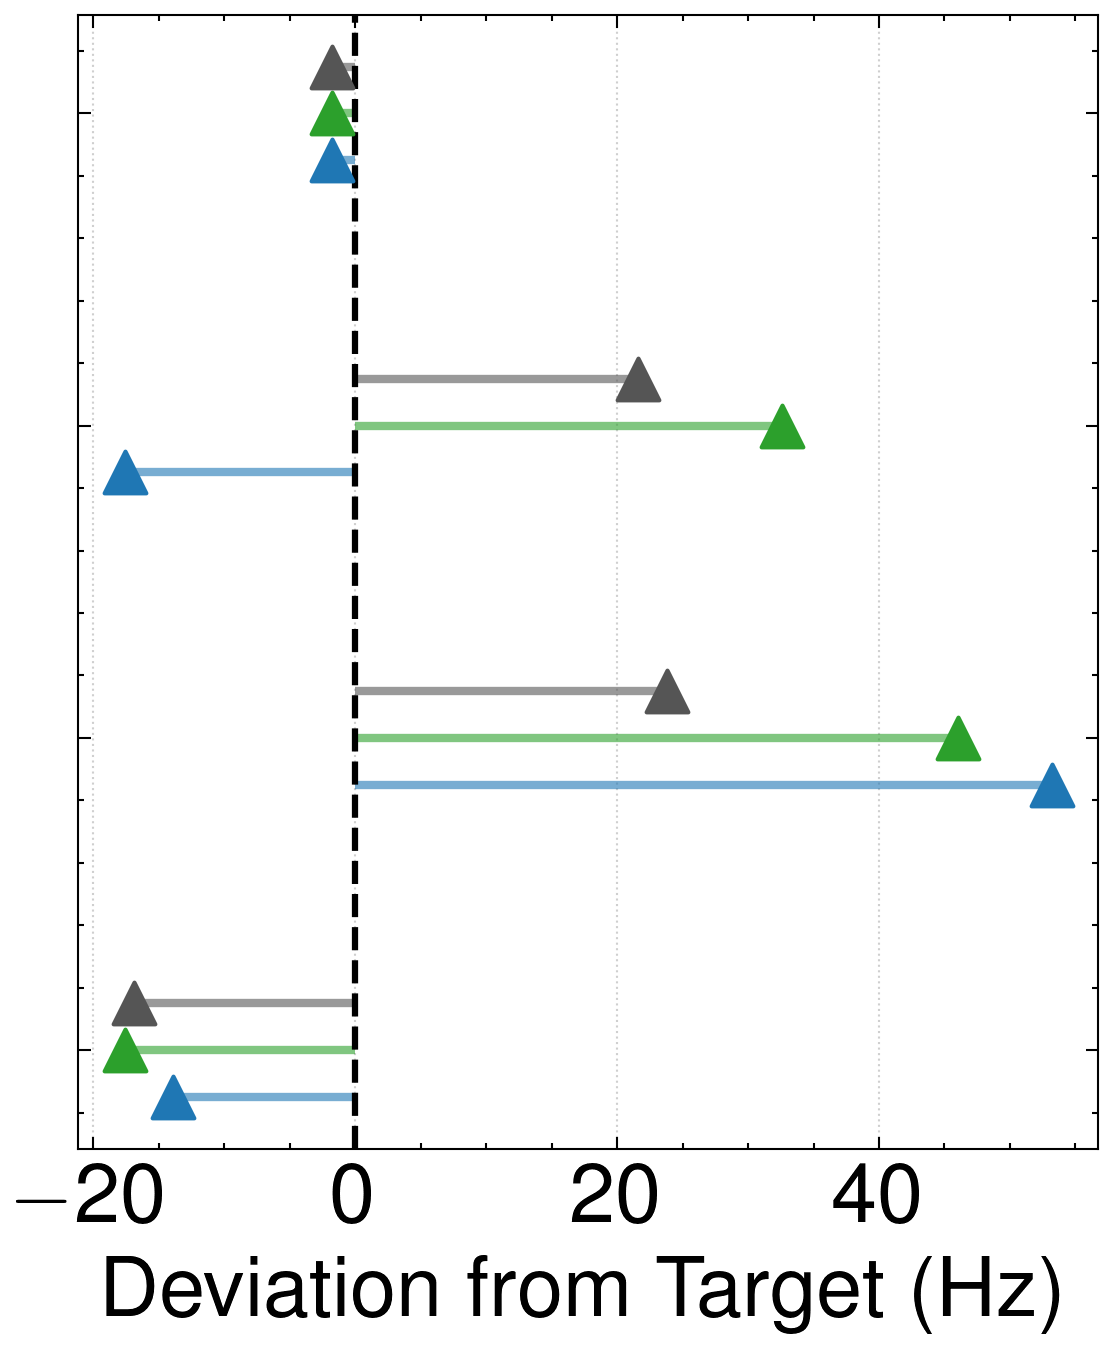

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

with rc_context():

    cell_type_to_metric = {
        'PYR': 'Principal output',
        'OLM': 'Dendritic Inhibition', 
        'BS': 'Fast Dendritic Inh.',
        'PVBC': 'Somatic Inhibition'
    }

    models_list = []
    metrics_list = []
    values_list = []
    targets_list = []

    for model_name in ['gpr', 'megp', 'joint-c+o']:
        for cell_type in ca1_culture_best_features['gpr']:
            if cell_type not in cell_type_to_metric:
                continue
            models_list.append(model_name)
            metrics_list.append(cell_type)
            values_list.append(ca1_culture_best_features[model_name][cell_type])
            targets_list.append(targets[cell_type])

    data = {
        'Model': models_list,
        'Metric': metrics_list,
        'Value': values_list,
        'Target': targets_list
    }

    df = pd.DataFrame(data)

    df['Metric_Display'] = df['Metric'].map(cell_type_to_metric)

    df['Deviation'] = (df['Value'] - df['Target'] )
    df['RelDeviation'] = ((df['Value'] - df['Target'] )/ df['Target']) * 100

    models = df['Model'].unique()
    metrics = df['Metric'].unique()
    colors = ['#1f77b4', '#2ca02c', '#555555']

    fig, ax = plt.subplots(figsize=(4, 5))

    y = np.arange(len(metrics))
    height = 0.15

    for i, model in enumerate(models):
        model_data = df[df['Model'] == model]

        position = y + (i - 1) * height

        ax.hlines(
            y=position, 
            xmin=0, 
            xmax=model_data['Deviation'], 
            color=colors[i], 
            alpha=0.6, 
            linewidth=2
        )

        ax.scatter(
            model_data['Deviation'],
            position, 
            color=colors[i], 
            s=100, 
            label=model, 
            zorder=3,
            marker='^'
        )

    

        # ax.text(
        #     10,  position[0],
        #     cell_type_to_metric.get(cell_type, cell_type),
        #     fontsize=11, fontweight='bold',
        #     va='bottom'
        # )
    print(df)


    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Target')

    ax.set_yticks(y)
    ax.set_yticklabels([])#[m] for m in metrics])


    ax.set_xlabel('Deviation from Target (Hz)')# fontsize=12)
    ax.xaxis.grid(True, linestyle=':', alpha=0.6)

    #ax.axvspan(-20, 20, color='yellow', alpha=0.05, zorder=0)

    #ax.legend(loc='upper right', fontsize=20)

    plt.tight_layout()

    plt.show()

In [119]:
stash("figure5/deviation-from-target", fig)

## Save solution

In [ ]:
best = {}
for q in _ca1_culture.components:
    best[q.mO] = {}
    for f in ('x', 'y', 'f', 'c'):
        best[q.mO][f] = q.get_best()[f].iloc[-1].to_dict()
    best[q.mO]['w'] = x_to_weight_dict(best[q.mO]['x'])

stash('ca1_slice-best', best)